In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('online_retail_II.csv')
print('Dataframe shape pre processing:', df.shape)
df.head(5)

Dataframe shape pre processing: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
df = df.dropna(subset=['Customer ID'])

df['Invoice'] = pd.to_numeric(df['Invoice'], errors='coerce')
df = df.dropna(subset=['Invoice'])

df = df[df['Quantity']>0]
df = df[df['Price'] >0]

df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['TotalPrice'] = df['Quantity'] * df['Price']


print(f"Cleaned shape: {df.shape}")
print(f"Unique customers: {df['Customer ID'].nunique()}")
print(f"Unique products: {df['StockCode'].nunique()}")
print(f"Date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
df.sample(n=5)

Cleaned shape: (805549, 9)
Unique customers: 5878
Unique products: 4631
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
313245,519882.0,21897,POTTING SHED CANDLE CITRONELLA,1,2010-08-22 11:45:00,2.95,16725,United Kingdom,2.95
940489,572513.0,22539,MINI JIGSAW DOLLY GIRL,1,2011-10-24 14:36:00,0.42,16728,United Kingdom,0.42
785919,559813.0,23306,SET OF 36 DOILIES PANTRY DESIGN,12,2011-07-12 15:42:00,1.45,18272,United Kingdom,17.40
964178,574328.0,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,12,2011-11-04 09:05:00,4.25,13081,United Kingdom,51.00
363392,524559.0,22677,"FRENCH BLUE METAL DOOR SIGN, 2",3,2010-09-29 14:37:00,1.25,17515,United Kingdom,3.75


In [8]:
df['InvoiceDate'].max()

'2011-12-09 12:50:00'

In [13]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [ ]:
# ── 3. RFM Feature Engineering ────────────────────────────────────────────────

# Snapshot date = 1 day after last transaction (standard RFM practice)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days), #how many days ago since purchase
    Frequency = ('Invoice',     'nunique'),       # number of distinct orders
    Monetary  = ('TotalPrice',  'sum') #Total money spent
).reset_index()

print(rfm.describe())

        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.000000   739.000000   398.000000  608821.650000


In [14]:
rfm.head(5)

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


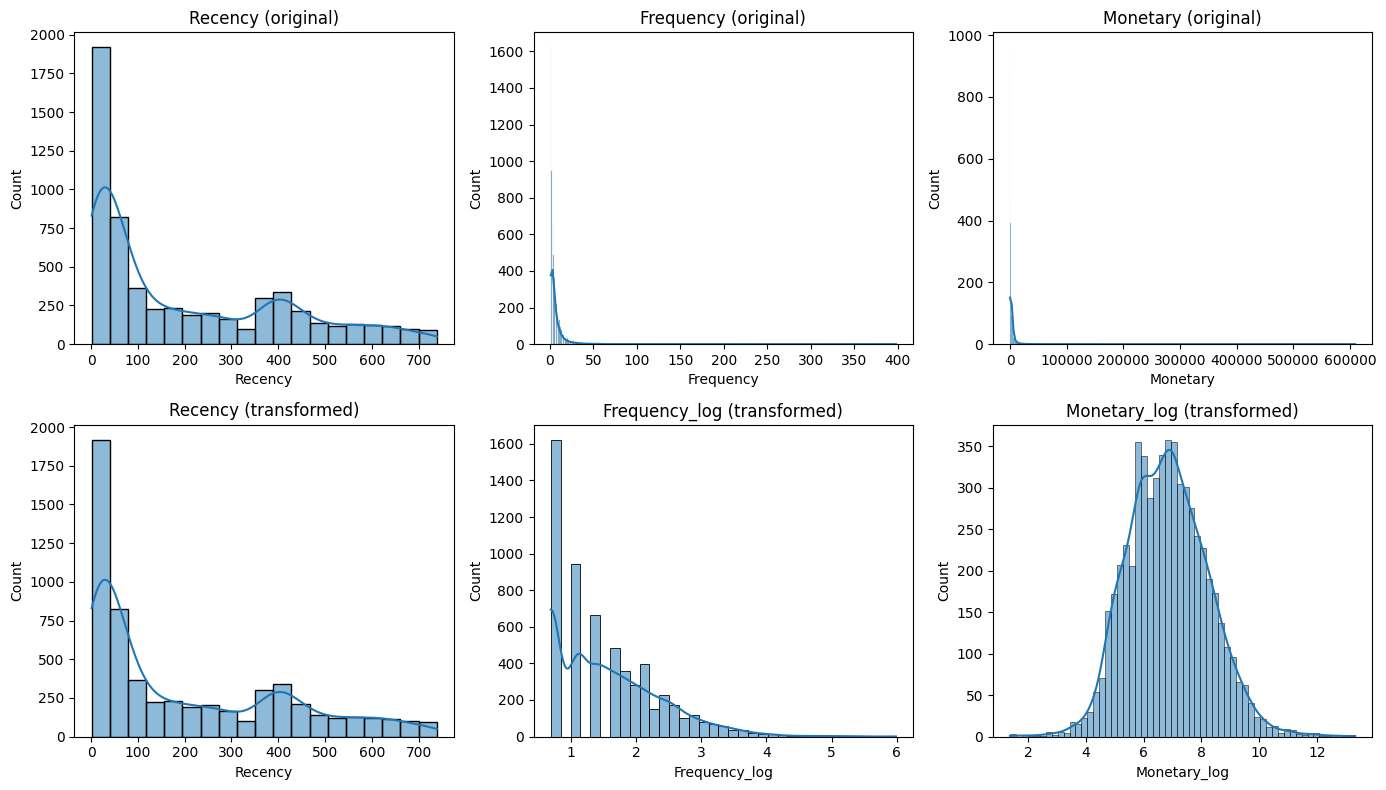

In [15]:
# ── 4. Handle Skewness (important before clustering) ─────────────────────────
# Monetary and Frequency are heavily right-skewed — log transform helps K-Means

rfm['Monetary_log']  = np.log1p(rfm['Monetary'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])

# Quick check
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes[0], ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], ax=ax, kde=True)
    ax.set_title(f'{col} (original)')
for ax, col in zip(axes[1], ['Recency', 'Frequency_log', 'Monetary_log']):
    sns.histplot(rfm[col], ax=ax, kde=True)
    ax.set_title(f'{col} (transformed)')
plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150)
plt.show()

In [20]:
rfm.head(5)

,Customer ID,Recency,Frequency,Monetary,Monetary_log,Frequency_log
0,12346,326,12,77556.46,11.258774,2.564949
1,12347,2,8,5633.32,8.636632,2.197225
2,12348,75,5,2019.40,7.611051,1.791759
3,12349,19,4,4428.69,8.396085,1.609438
4,12350,310,1,334.40,5.815324,0.693147


In [16]:
# ── 5. Normalize for Clustering ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

features = rfm[['Recency', 'Frequency_log', 'Monetary_log']].copy()
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

print("RFM scaled — ready for Step 2 (Cluster Analysis)")
print(f"Shape: {rfm_scaled.shape}")

RFM scaled — ready for Step 2 (Cluster Analysis)
Shape: (5878, 3)


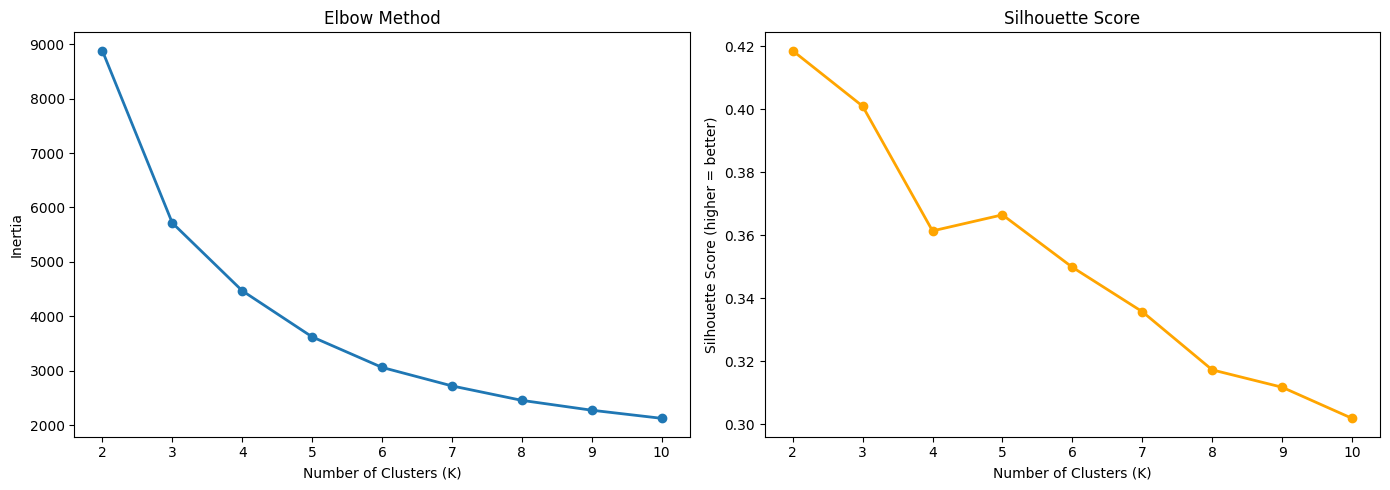

Silhouette scores:
  K=2: 0.4186
  K=3: 0.4010
  K=4: 0.3614
  K=5: 0.3665
  K=6: 0.3499
  K=7: 0.3357
  K=8: 0.3173
  K=9: 0.3117
  K=10: 0.3019


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Test K from 2 to 10
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

# Plot elbow + silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', linewidth=2)
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouette_scores, marker='o', linewidth=2, color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')

plt.tight_layout()
plt.savefig('cluster_selection.png', dpi=150)
plt.show()

print("Silhouette scores:")
for k, s in zip(K_range, silhouette_scores):
    print(f"  K={k}: {s:.4f}")

In [22]:
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Check how many customers landed in each cluster
print(rfm['Cluster'].value_counts().sort_index())

Cluster
0    1638
1    1384
2    1891
3     965
Name: count, dtype: int64


In [24]:
rfm.head(5)

,Customer ID,Recency,Frequency,Monetary,Monetary_log,Frequency_log,Cluster
0,12346,326,12,77556.46,11.258774,2.564949,3
1,12347,2,8,5633.32,8.636632,2.197225,3
2,12348,75,5,2019.40,7.611051,1.791759,2
3,12349,19,4,4428.69,8.396085,1.609438,2
4,12350,310,1,334.40,5.815324,0.693147,0


In [25]:
# Look at average RFM values per cluster (use originals, not scaled)
cluster_summary = rfm.groupby('Cluster').agg(
    Recency_mean   = ('Recency',   'mean'),
    Frequency_mean = ('Frequency', 'mean'),
    Monetary_mean  = ('Monetary',  'mean'),
    Customer_count = ('Customer ID', 'count')
).round(1)

print(cluster_summary)

         Recency_mean  Frequency_mean  Monetary_mean  Customer_count
Cluster                                                             
0               493.5             1.7          538.4            1638
1               106.2             1.7          425.8            1384
2                98.8             5.5         1910.0            1891
3                42.7            22.2        13119.7             965


In [26]:

cluster_labels = {
    3: 'Champions',
    2: 'Loyal',
    1: 'At-Risk',
    0: 'Dormant'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
print(rfm['Segment'].value_counts())

Segment
Loyal        1891
Dormant      1638
At-Risk      1384
Champions     965
Name: count, dtype: int64


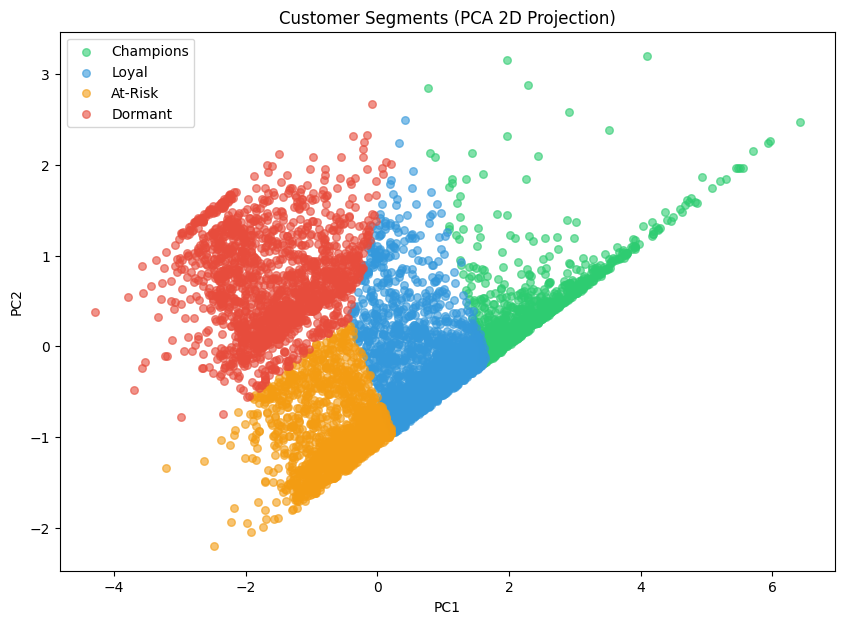

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(10, 7))
colors = {'Champions': '#2ecc71', 'Loyal': '#3498db', 
          'At-Risk': '#f39c12', 'Dormant': '#e74c3c'}

for segment, color in colors.items():
    mask = rfm['Segment'] == segment
    plt.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1], 
                c=color, label=segment, alpha=0.6, s=30)

plt.title('Customer Segments (PCA 2D Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.savefig('cluster_pca.png', dpi=150)
plt.show()

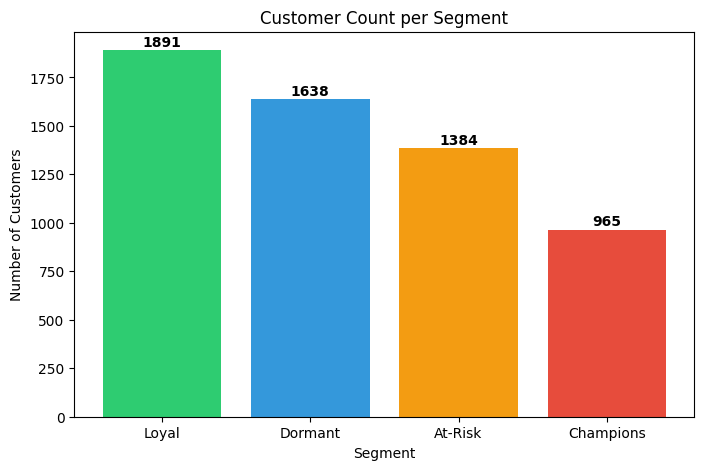

In [30]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(segment_counts.index, segment_counts.values, 
               color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'])
plt.title('Customer Count per Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
             str(val), ha='center', fontweight='bold')
plt.savefig('segment_counts.png', dpi=150)
plt.show()

In [31]:
# Save the RFM + cluster labels — Step 3 (NCF) will need this
rfm.to_csv('rfm_clustered.csv', index=False)
print("Saved rfm_clustered.csv")
print(rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head(10))

Saved rfm_clustered.csv
   Customer ID  Recency  Frequency  Monetary  Cluster    Segment
0        12346      326         12  77556.46        3  Champions
1        12347        2          8   5633.32        3  Champions
2        12348       75          5   2019.40        2      Loyal
3        12349       19          4   4428.69        2      Loyal
4        12350      310          1    334.40        0    Dormant
5        12351      375          1    300.93        0    Dormant
6        12352       36         10   2849.84        2      Loyal
7        12353      204          2    406.76        1    At-Risk
8        12354      232          1   1079.40        1    At-Risk
9        12355      214          2    947.61        1    At-Risk
